# Aluminium smelting electricity generation mix, 16 scenarios

Self contained. Everything the figure does is in the cells below, so you can edit any label,
position or size directly. No imports from `common.py`. Columns are GCAM ambition scenarios
(SSP-RCP pairs); rows are the CCS regime. Interim stand-in GCAM runs.

In [22]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RUNS = Path("../../runs")

# rows: CCS regime, top to bottom
ROWS = [("none",      "No CCS"),
        ("low",       "Low Limit CCS"),
        ("high",      "High Limit CCS"),
        ("unlimited", "Unlimited CCS")]
# columns: GCAM ambition scenario (SSP-RCP pair), most -> least ambitious
COLUMNS = [("SSP1_1p9", "SSP1-1.9"),
           ("SSP1_2p6", "SSP1-2.6"),
           ("SSP2_3p7", "SSP2-3.7"),
           ("SSP2_4p5", "SSP2-4.5")]

# Non-capture power sources keep their groups. Captive-power capture is split into retrofit
# (an existing plant renovated in place) and newbuild (greenfield or rebuild), in two
# terracotta shades so the two kinds of CCS read apart within the mix.
GROUPS = {"Fossil fuel":              ["Coal", "Natural Gas"],
          "Grid":                     ["Grid"],
          "Power purchase agreement": ["PPA+Grid"],
          "Hydro":                    ["Hydro"],
          "Nuclear":                  ["Small Modular Reactor"]}
SOURCE_TO_GROUP = {s: g for g, ss in GROUPS.items() for s in ss}

# Stack order: fossil, the two capture bands, then the clean sources.
GROUP_ORDER = ["Fossil fuel", "CCS retrofit", "CCS newbuild",
               "Grid", "Power purchase agreement", "Hydro", "Nuclear"]
COLOURS = {"Fossil fuel": "#8d8d8d",
           "CCS retrofit": "#e08e79",     # the original capture colour - renovated existing plant
           "CCS newbuild": "#a83e2c",     # terracotta - greenfield / rebuild
           "Grid": "#f2c14e", "Power purchase agreement": "#c9a227",
           "Hydro": "#8ab6d6", "Nuclear": "#3d6b8c"}

plt.rcParams.update({"font.family": "sans-serif", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": False})

## Load the sixteen runs

In [24]:
def load_mix(ccs, grid):
    """Smelter production by power-source group and year, Mt. Captive-power capture is split
    into retrofit and newbuild from the plant stack transition record (status per plant-year)."""
    name = f"{grid}_{ccs}"
    path = glob.glob(str(RUNS / name / "smelter" / "final" / "plant_stack_transition_*.csv"))[0]
    d = pd.read_csv(path)
    d["power"] = d["technology"].str.split(" + ", n=1, regex=False).str[1]

    # Plant-level origin: a plant that was ever greenfield-built or rebuilt is new capacity,
    # even if it started unabated and was retrofitted to CCS later. Only plants from the
    # initial 2020 stock, retrofitted in place, count as retrofit CCS. The concern is building
    # new plants that carry CCS at all, so newbuild follows the plant, not the CCS switch year.
    ever_new = d.groupby("uuid")[["greenfield_status", "rebuild_status"]].any().any(axis=1)
    d["ever_new"] = d["uuid"].map(ever_new)

    def classify(row):
        if str(row["power"]).endswith("+CCS"):
            return "CCS newbuild" if row["ever_new"] else "CCS retrofit"
        return SOURCE_TO_GROUP.get(row["power"])
    d["group"] = d.apply(classify, axis=1)

    mix = d.pivot_table(index="year", columns="group", values="annual_production_volume",
                        aggfunc="sum")
    mix = mix.reindex(range(2020, 2051)).fillna(0.0)
    for group in GROUP_ORDER:          # keep every group present so colours never shift
        if group not in mix.columns:
            mix[group] = 0.0
    return mix[GROUP_ORDER]


mixes = {(ccs, grid): load_mix(ccs, grid)
         for ccs, _ in ROWS for grid, _ in COLUMNS}

print(f"loaded {len(mixes)} runs")
mixes[("unlimited", "SSP1_1p9")].loc[[2020, 2035, 2050]].round(1)

loaded 16 runs


group,Fossil fuel,CCS retrofit,CCS newbuild,Grid,Power purchase agreement,Hydro,Nuclear
year,,,,,,,
2020,36.0,0.0,0.0,16.0,6.1,7.4,0.0
2035,6.6,3.8,46.0,29.8,4.0,7.5,0.0
2050,0.0,3.8,54.6,33.0,4.9,7.5,16.8


## The figure

Every number that positions something is in this cell. The three left-hand labels sit at
`x=0.008`, the rotated unit label at `x=0.048`, and `rect` in `tight_layout` reserves the
space they sit in.

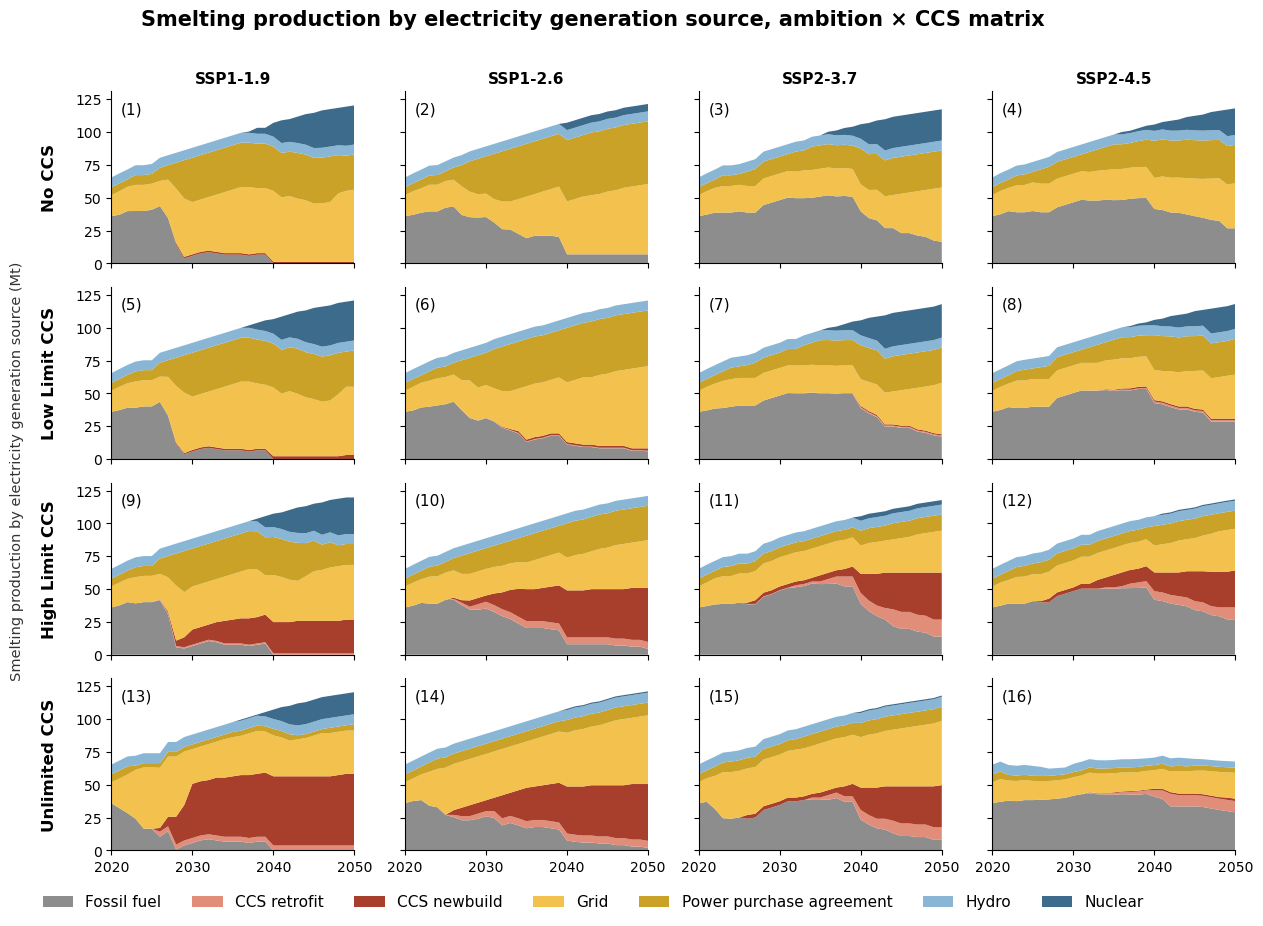

In [26]:
TITLE = "Smelting production by electricity generation source, ambition \u00d7 CCS matrix"
Y_LABEL = "Smelting production by electricity generation source (Mt)"

ymax = max(m.sum(axis=1).max() for m in mixes.values()) * 1.08

fig, axes = plt.subplots(len(ROWS), len(COLUMNS), figsize=(13.5, 11.5),
                         sharex=True, sharey=True)

panel_number = 1
for row, (ccs, row_label) in enumerate(ROWS):
    for col, (grid, col_title) in enumerate(COLUMNS):
        ax = axes[row, col]
        mix = mixes[(ccs, grid)]
        ax.stackplot(mix.index, [mix[g].values for g in GROUP_ORDER],
                     colors=[COLOURS[g] for g in GROUP_ORDER], labels=GROUP_ORDER)
        ax.set_xlim(2020, 2050)
        ax.set_xticks([2020, 2030, 2040, 2050])
        ax.set_ylim(0, ymax)
        ax.tick_params(labelsize=10)
        ax.text(0.04, 0.94, f"({panel_number})", transform=ax.transAxes,
                ha="left", va="top", fontsize=11)
        panel_number += 1
        if row == 0:
            ax.set_title(col_title, fontsize=11, fontweight="bold")

fig.suptitle(TITLE, fontsize=15, fontweight="bold", y=0.955)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=7, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, 0.16))

# rect leaves room on the left for the two label columns, and at the bottom for the legend
fig.tight_layout(rect=[0.105, 0.19, 1, 0.945])
fig.canvas.draw()                       # so get_position below returns the final layout

# left-hand labels: CCS regime outboard
for row, (ccs, row_label) in enumerate(ROWS):
    box = axes[row, 0].get_position()
    fig.text(0.092, (box.y0 + box.y1) / 2, row_label, rotation=90,
             ha="left", va="center", fontsize=12, fontweight="bold")

top = axes[0, 0].get_position()
bottom = axes[-1, 0].get_position()
fig.text(0.068, (top.y1 + bottom.y0) / 2, Y_LABEL, rotation=90,
         ha="left", va="center", fontsize=10.5, color="#333333")

for extension in ("png", "svg"):
    fig.savefig(f"../../figures/electricity_generation_mix.{extension}", dpi=200,
                bbox_inches="tight")
plt.show()

## The figure, normalised to % of total generation by source

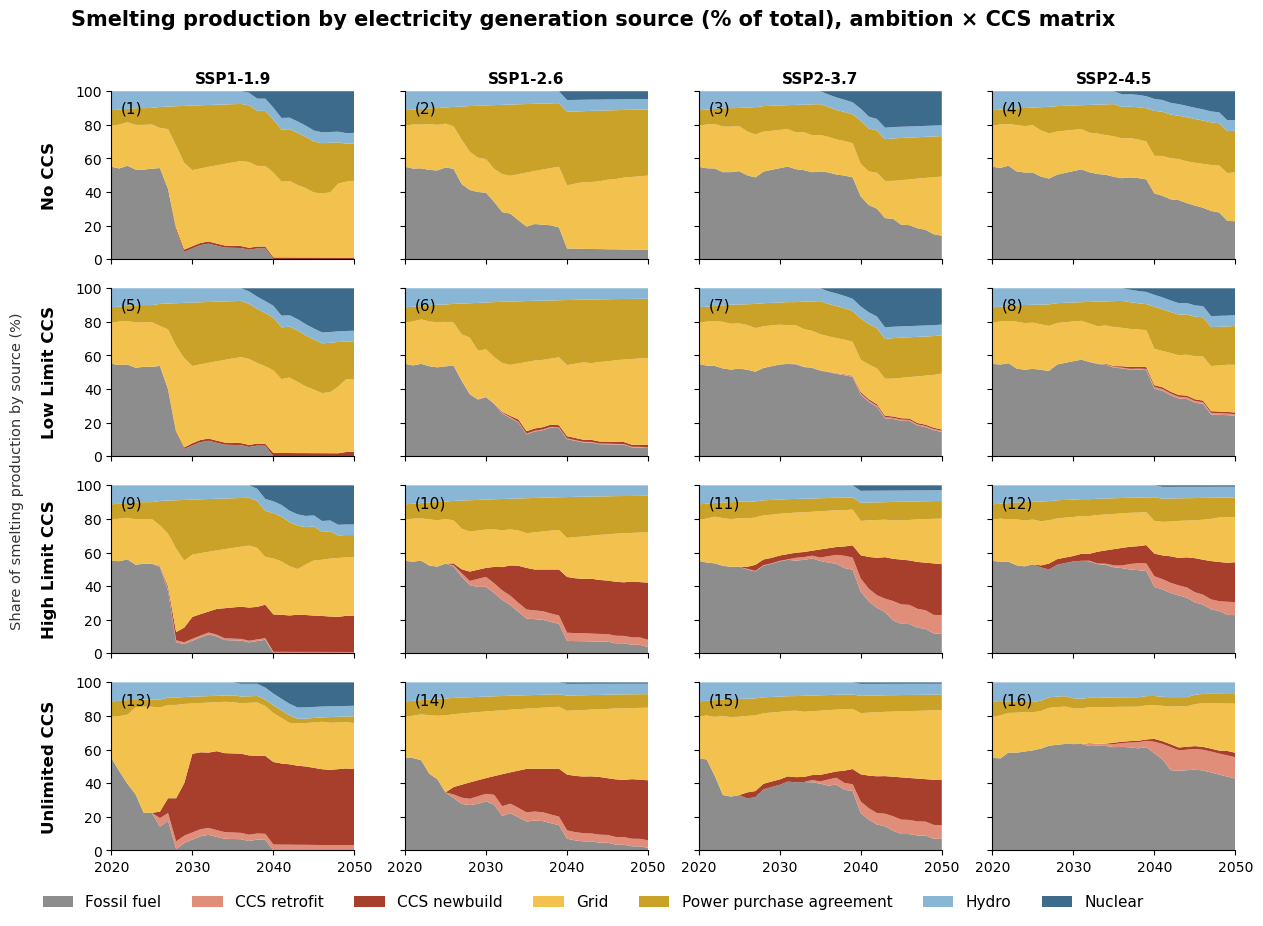

In [28]:
# Same 16-panel matrix, normalised so each year's stack sums to 100% (share of production by source).
TITLE_PCT = "Smelting production by electricity generation source (% of total), ambition × CCS matrix"
Y_LABEL_PCT = "Share of smelting production by source (%)"

fig, axes = plt.subplots(len(ROWS), len(COLUMNS), figsize=(13.5, 11.5), sharex=True, sharey=True)

panel_number = 1
for row, (ccs, row_label) in enumerate(ROWS):
    for col, (grid, col_title) in enumerate(COLUMNS):
        ax = axes[row, col]
        mix = mixes[(ccs, grid)]
        total = mix.sum(axis=1)
        pct = mix.div(total.where(total > 0), axis=0).fillna(0.0) * 100
        ax.stackplot(pct.index, [pct[g].values for g in GROUP_ORDER],
                     colors=[COLOURS[g] for g in GROUP_ORDER], labels=GROUP_ORDER)
        ax.set_xlim(2020, 2050); ax.set_xticks([2020, 2030, 2040, 2050])
        ax.set_ylim(0, 100); ax.tick_params(labelsize=10)
        ax.text(0.04, 0.94, f"({panel_number})", transform=ax.transAxes, ha="left", va="top", fontsize=11)
        panel_number += 1
        if row == 0:
            ax.set_title(col_title, fontsize=11, fontweight="bold")

fig.suptitle(TITLE_PCT, fontsize=15, fontweight="bold", y=0.955)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=7, frameon=False, fontsize=11, bbox_to_anchor=(0.5, 0.16))
fig.tight_layout(rect=[0.105, 0.19, 1, 0.945])
fig.canvas.draw()
for row, (ccs, row_label) in enumerate(ROWS):
    box = axes[row, 0].get_position()
    fig.text(0.092, (box.y0 + box.y1) / 2, row_label, rotation=90, ha="left", va="center", fontsize=12, fontweight="bold")
top = axes[0, 0].get_position(); bottom = axes[-1, 0].get_position()
fig.text(0.068, (top.y1 + bottom.y0) / 2, Y_LABEL_PCT, rotation=90, ha="left", va="center", fontsize=10.5, color="#333333")
for extension in ("png", "svg"):
    fig.savefig(f"../../figures/electricity_generation_mix_pct.{extension}", dpi=200, bbox_inches="tight")
plt.show()
